# Thymocyte frequency plots with age 

Run using `aging_thymus` conda environment 

In [3]:
import matplotlib.pyplot as plt 
import os 
import re
import numpy as np
import pandas as pd 
import anndata as ad
import seaborn as sns
data_dir = "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/"

In [4]:
core_tag_order = [
    "A3_18wkF",
    "A1_20wkM",
    "T2056-2_0.008M",
    "T2087-2_0.003M",
    "T2019-2_0.013F",
    "T2077-1_0.013F",
    "T2049-1_0.013M",
    "T2052-1_0.021M",
    "T2110-1_0.025M",
    "T2018-3_0.3F",
    "T2047-1_0.333F",
    "T2092-4_0.833M",
    "T2083-1_0.917F",
    "T2101-1_1M",
    "T2044-2_1.166F",
    "T2037-3_1.583M",
    "P49_2M", 
    "T2036-3_7F",
    "T2008_7M", 
    "T2066_8M", 
    "T2040-2_8F",
    "T2033_9F", 
    "P33_10M", 
    "P57_17F",
    "P52_21M",
    "T2095-2_22M",
    "P31_27F", 
    "P34_29F",
    "P35_38F",
    "P32_46F",
    "P42_54F",
    "P41-E1_58F",
    "P37_62F",
    "P44_64F",
    "P36_67F"
]
print(len(core_tag_order))

35


# Data

In [9]:
thym_ad = ad.read_h5ad(os.path.join(data_dir, "all_thym_w_annotations_2026-02-24.h5ad"))
thym_ad = thym_ad[~thym_ad.obs["age"].isin(["2026-01-29.h5ad", "annotations.h5ad"]), :].copy()
thym_ad.obs["num_age"] = thym_ad.obs["age"].str.replace(r"(F|M|wkM|wkF)", "", regex=True).astype(float)

obs = thym_ad.obs
conditions = [
    obs["age"].str.contains("wk", na=False),
    (obs["num_age"] > 0) & (obs["num_age"] <= 0.25),
    (obs["num_age"] > 0.25) & (obs["num_age"] <= 2),
    (obs["num_age"] > 2) & (obs["num_age"] <= 10),
    (obs["num_age"] > 10) & (obs["num_age"] <= 40),
    (obs["num_age"] > 40) & (obs["num_age"] <= 60),
    (obs["num_age"] > 60)
]

choices = [
    "Fetal",
    "Newborn",
    "Infant",
    "Child",
    "Young Adult",
    "Middle Aged",
    "Older Adult"
]

thym_ad.obs["age_group"] = np.select(conditions, choices, default=np.nan)
age_group_cat = pd.CategoricalDtype(categories = ["Fetal", "Newborn", "Infant", "Child", "Young Adult", "Middle Aged", "Older Adult"], ordered = True)
thym_ad.obs["age_group"] = thym_ad.obs["age_group"].astype(age_group_cat)

/stor/work/Ehrlich/Users/John/mamba/envs/aging_thymus/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/stor/work/Ehrlich/Users/John/mamba/envs/aging_thymus/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
out = thym_ad.obs.copy()
out["n_ct_samp"] = out.groupby(["thym_ct_svm_pred", "core_tag"])["thym_ct_svm_pred"].transform("size")
out["n_samp"] = out.groupby("core_tag")["core_tag"].transform("size")
out["prop_ct_samp"] = out["n_ct_samp"] / out["n_samp"]
out["n_ct_age"] = out.groupby(["age_group", "thym_ct_svm_pred"])["thym_ct_svm_pred"].transform("size")
out["n_ct"] = out.groupby("thym_ct_svm_pred")["thym_ct_svm_pred"].transform("size")
out["prop_ct_age_group"] = out["n_ct_age"] / out["n_ct"]

# The age grouping should instead be the mean of the pseudobulk proportions, but I'll see how Anastasia does it. 
out = out[["core_tag", "thym_ct_svm_pred", "age_group", "n_ct_samp", "n_samp", "prop_ct_samp", "prop_ct_age_group"]].drop_duplicates().reset_index(drop=True)
out = out.rename(columns= {"thym_ct_svm_pred" : "cell_type"})
out

/tmp/ipykernel_2868657/2037912401.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out["n_ct_samp"] = out.groupby(["thym_ct_svm_pred", "core_tag"])["thym_ct_svm_pred"].transform("size")
/tmp/ipykernel_2868657/2037912401.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out["n_samp"] = out.groupby("core_tag")["core_tag"].transform("size")
/tmp/ipykernel_2868657/2037912401.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

,core_tag,cell_type,age_group,n_ct_samp,n_samp,prop_ct_samp,prop_ct_age_group
0,A1_20wkM,DN,Fetal,26856,195174,0.137600,0.070783
1,A1_20wkM,DP_Q,Fetal,103714,195174,0.531393,0.058941
2,A1_20wkM,Treg,Fetal,3882,195174,0.019890,0.040608
3,A1_20wkM,DP_P,Fetal,37740,195174,0.193366,0.039885
4,A1_20wkM,CD8SP,Fetal,14030,195174,0.071885,0.058171
...,...,...,...,...,...,...,...
205,T2110-1_0.025M,DP_Q,Newborn,22072,61967,0.356190,0.220903
206,T2110-1_0.025M,CD8SP,Newborn,4986,61967,0.080462,0.259852
207,T2110-1_0.025M,DN,Newborn,8507,61967,0.137283,0.194276
208,T2110-1_0.025M,Treg,Newborn,2097,61967,0.033841,0.303703


In [19]:
out.to_csv(os.path.join( "/stor/scratch/Ehrlich/MxIF/aging_thymus/human_images/human_blocks/", "thymocyte_annotations_per_sample_2026-02-24.csv"), index=False)

In [12]:
core_tag_order = [
    "A3_18wkF",
    "A1_20wkM",
    "T2056-2_0.008M",
    "T2087-2_0.003M",
    "T2019-2_0.013F",
    "T2077-1_0.013F",
    "T2049-1_0.013M",
    "T2052-1_0.021M",
    "T2110-1_0.025M",
    "T2018-3_0.3F",
    "T2047-1_0.333F",
    "T2092-4_0.833M",
    "T2083-1_0.917F",
    "T2101-1_1M",
    "T2044-2_1.166F",
    "T2037-3_1.583M",
    "P49_2M", 
    "T2036-3_7F",
    "T2008_7M", 
    "T2066_8M", 
    "T2040-2_8F",
    "T2033_9F", 
    "P33_10M", 
    "P57_17F",
    "P52_21M",
    "T2095-2_22M",
    "P31_27F", 
    "P34_29F",
    "P35_38F",
    "P32_46F",
    "P42_54F",
    "P41-E1_58F",
    "P37_62F",
    "P44_64F",
    "P36_67F"
]
core_tag_type= pd.CategoricalDtype(categories= core_tag_order, ordered= True)
out["core_tag"] = out["core_tag"].astype(core_tag_type)

In [13]:
out = out.rename(columns= {"thym_ct_svm_pred" : "cell_type"})
out.loc[:, ["core_tag", "cell_type", "age_group", "prop_ct_samp"]]

,core_tag,cell_type,age_group,prop_ct_samp
0,A1_20wkM,DN,Fetal,0.137600
1,A1_20wkM,DP_Q,Fetal,0.531393
2,A1_20wkM,Treg,Fetal,0.019890
3,A1_20wkM,DP_P,Fetal,0.193366
4,A1_20wkM,CD8SP,Fetal,0.071885
...,...,...,...,...
205,T2110-1_0.025M,DP_Q,Newborn,0.356190
206,T2110-1_0.025M,CD8SP,Newborn,0.080462
207,T2110-1_0.025M,DN,Newborn,0.137283
208,T2110-1_0.025M,Treg,Newborn,0.033841


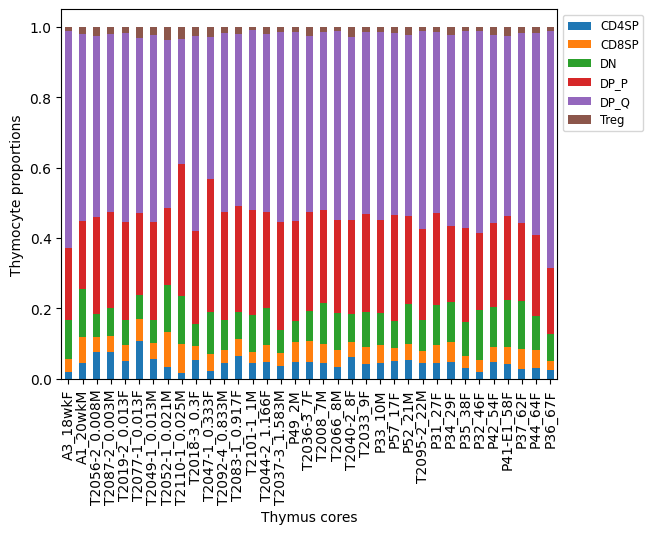

In [14]:
ax = out.loc[:, ["core_tag", "prop_ct_samp", "cell_type"]].pivot(index='core_tag', columns='cell_type', values='prop_ct_samp').plot(kind='bar', stacked=True, title='')
ax.set_ylabel('Thymocyte proportions')
ax.set_xlabel("Thymus cores")
ax.legend(
    bbox_to_anchor=(1.0, 1.0),
    fontsize='small'
)
plt.show()

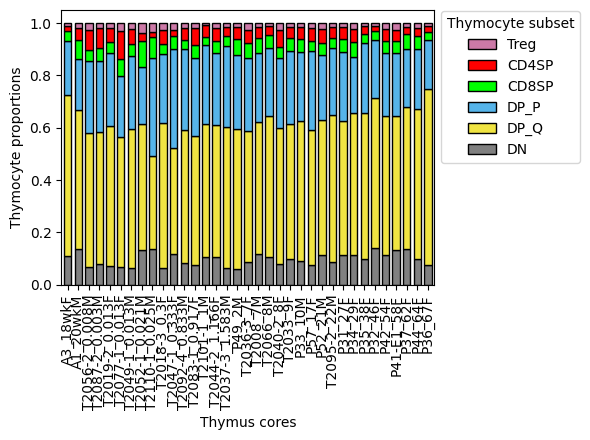

In [15]:
plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["axes.grid"] = False

color_list = ["#808080",
 "#F0E442",
   "#56B4E9",
     "#00FF00",
  "#FF0000",
 "#CC79A7"]
thym_levels= pd.CategoricalDtype(categories= ["DN", "DP_Q", "DP_P", "CD8SP", "CD4SP", "Treg"], ordered = True)
tmp = out.loc[:, ["core_tag", "prop_ct_samp", "cell_type"]].copy()
tmp["cell_type"] = tmp["cell_type"].astype(thym_levels)
tmp = tmp.pivot(index='core_tag', columns='cell_type', values='prop_ct_samp')


ax = tmp.plot(kind='bar', stacked=True, width=0.7, edgecolor = "black", color=color_list)
plt.legend().remove()
ax.legend(title='Thymocyte subset', bbox_to_anchor=(1, 1.02), loc='upper left', reverse= True)
ax.set_ylabel('Thymocyte proportions')
ax.set_xlabel("Thymus cores")
plt.tight_layout()
# plt.savefig('figures/barlot_Tcells (counts).pdf')

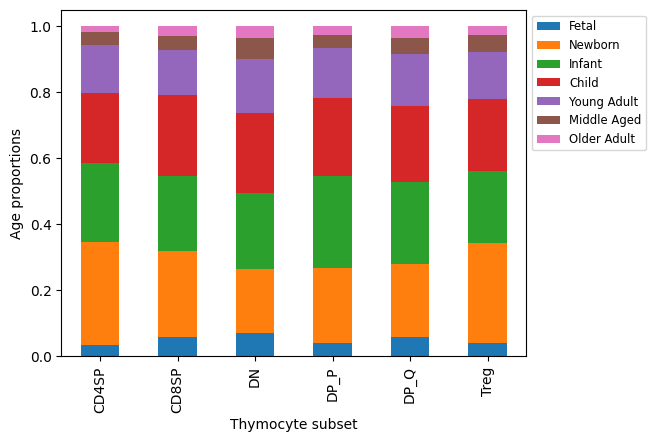

In [18]:
ax = out.loc[:, ["age_group", "prop_ct_age_group", "cell_type"]].drop_duplicates().pivot(index='cell_type', columns='age_group', values='prop_ct_age_group').plot(kind='bar', stacked=True, title='')
ax.set_ylabel('Age proportions')
ax.set_xlabel("Thymocyte subset")
ax.legend(
    bbox_to_anchor=(1.0, 1.0),
    fontsize='small'
)
plt.show()